# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased. 

The equation governing the static response of the rod is: 
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young’s modulus 
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

### The goals
- Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$
- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.
  
### Dataset
The observation and the ground truth references are given in the dataset ```ProblemA_dataset.h5```:
- ```x_obs```: the observation sensors 
- ```u_obs```: the observed displacement field $u$ (contaminated by noise)
- ```x_test```: the locations where the ground truth is evaluated (Used for computing error and should **not** be used for training)
- ```k_test```: the ground truth reference for Young's modulus (Used for computing error and should **not** be used for training)
- ```u_test```: the ground truth reference for displacement field (Used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']>


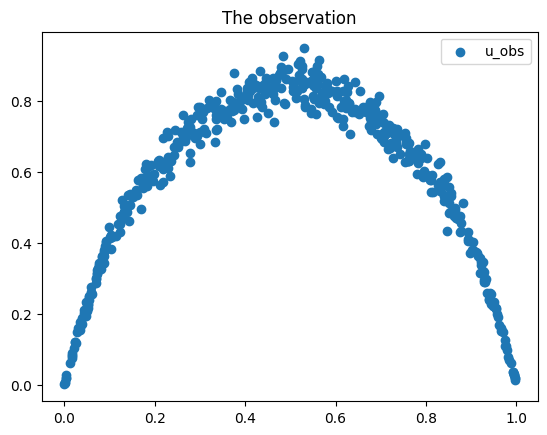

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
#
with h5py.File('ProblemA_dataset.h5', 'r') as file:
    print(file.keys())
    #
    x_obs = np.array(file['x_obs']).reshape(-1,1)
    u_obs = np.array(file['u_obs']).reshape(-1,1)
#
plt.figure()
plt.scatter(x_obs, u_obs, label='u_obs')
plt.title('The observation')
plt.legend()
plt.show()

- Goal 1: Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it

The problem can be categorized as a single-instance inverse coefficient problem. Due to the inverse nature of the problem where we want to recover the $k(x)$ value the best option will be to use a Physics-Informed Neural Network. While there are other more convoluted methods to achieve a similar solution, we simply do not have the necessary amound of data (500 points) to achieve it. We build two different networks, one for u and another one for k.

- Goal 2: Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.

Both networks are an MLP of one input, one output and three hidden layers of 64 nodes. 

The activation function of choice is a TanH because the PDE resiudal loss requires computing $u_\theta''(x)$ (via $\frac{d}{dx}(k \cdot u')$) through autodiff. 

The optimizer is an Adam optimizer, it keeps two running exponential averages computed from the gradient $g_t$ at each step. Firstly it smooths out noisy gradients and then it averages out the recent squared gradients so that parameters with small consistent gradients get bigger effective steps with the opposite effect for parameters with large or noisy gradients.

There are 20000 full-batch steps.

Other tricks for improvement: Hard BC, u(0) and u(L) equal zero by construction; Positivity reparametrization, makes the network always satisfy the condition that Young's modulus must be positive; Fresh Collocation Resampling, every training step and draws a brand-new set of 2000 random points in $(0, L)$ to evaluate the PDE residual on and Learning Rate Decay, where the scheduler halves the LR every 5000 epochs to avoid overshooting as we approach the minimum.  

- Goal 3: Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$


L2 error:  k = 0.0779   u = 0.0039


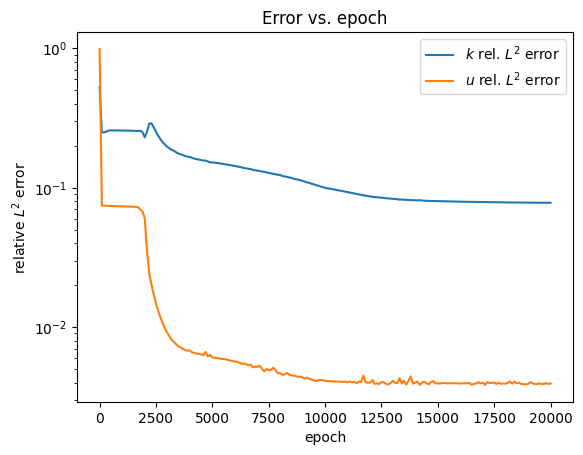

In [6]:
import torch
import torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda')

L = 1.0
f = 9.81

with h5py.File('ProblemA_dataset.h5', 'r') as file:
    x_obs  = np.array(file['x_obs']).reshape(-1, 1)
    u_obs  = np.array(file['u_obs']).reshape(-1, 1)
    x_test = np.array(file['x_test']).reshape(-1, 1)
    k_test = np.array(file['k_test']).reshape(-1, 1)
    u_test = np.array(file['u_test']).reshape(-1, 1)

def T(a): 
    return torch.tensor(a, dtype=torch.float32, device=device)

x_obs_t = T(x_obs)
u_obs_t = T(u_obs)

x_test_t = T(x_test)
k_test_t = T(k_test)
u_test_t = T(u_test)

def mlp(layers, act=nn.Tanh):
    m = []
    for i in range(len(layers) - 1):
        m.append(nn.Linear(layers[i], layers[i + 1]))
        if i < len(layers) - 2: 
            m.append(act())
    return nn.Sequential(*m)

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.u_raw = mlp([1, 64, 64, 64, 1])
        self.k_raw = mlp([1, 64, 64, 64, 1])
    def u(self, x):                    
        return x * (L - x) * self.u_raw(x)
    def k(self, x):
        return torch.nn.functional.softplus(self.k_raw(x)) + 0.1

net = PINN().to(device)
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=5000, gamma=0.5)

w_u = 1.0 
w_r = 0.1

N_col = 2000
EPOCHS = 20000
EVAL_EVERY = 100

def grad(y, x):
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]

def l2rel(pred, true):
    return torch.sqrt(torch.sum((pred - true) ** 2) / torch.sum(true ** 2)).item()

# LOOP
ep_hist, ek_hist, eu_hist = [], [], []
for ep in range(EPOCHS + 1):
    net.train(); opt.zero_grad()

    loss_u = torch.mean((net.u(x_obs_t) - u_obs_t) ** 2)

    xc = torch.rand(N_col, 1, device=device, requires_grad=True) * L
    ux = grad(net.u(xc), xc)
    flux = net.k(xc) * ux
    flux_x = grad(flux, xc)
    loss_r = torch.mean(((-flux_x - f) / f) ** 2)

    (w_u * loss_u + w_r * loss_r).backward()
    opt.step(); sched.step()

    if ep % EVAL_EVERY == 0:
        net.eval()
        with torch.no_grad():
            ek = l2rel(net.k(x_test_t), k_test_t)
            eu = l2rel(net.u(x_test_t), u_test_t)
        ep_hist.append(ep); ek_hist.append(ek); eu_hist.append(eu)

print(f'L2 error:  k = {ek_hist[-1]:.4f}   u = {eu_hist[-1]:.4f}')

net.eval()
with torch.no_grad():
    k_pred = net.k(x_test_t).cpu().numpy()
    u_pred = net.u(x_test_t).cpu().numpy()

plt.figure()
plt.semilogy(ep_hist, ek_hist, label='$k$ rel. $L^2$ error')
plt.semilogy(ep_hist, eu_hist, label='$u$ rel. $L^2$ error')
plt.xlabel('epoch'); plt.ylabel('relative $L^2$ error')
plt.title('Error vs. epoch'); plt.legend(); plt.show()

- Goal 4: Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.

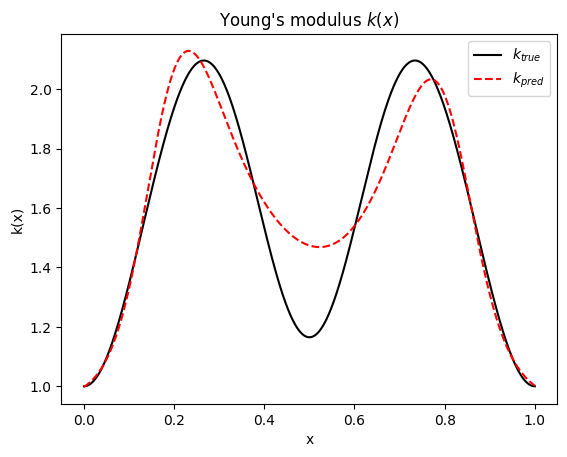

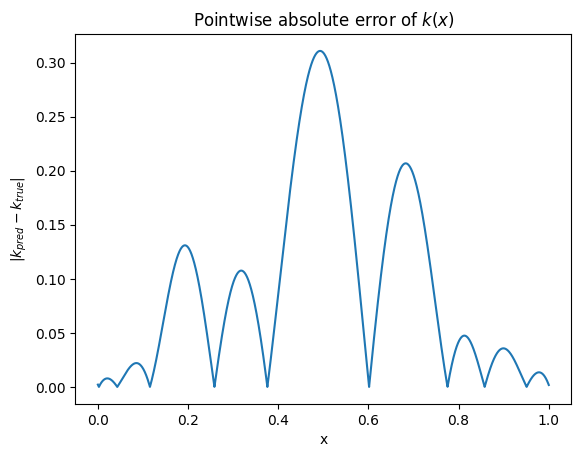

In [7]:
# Predicted Solution vs. Ground Truth Reference
plt.figure()
plt.plot(x_test, k_test, 'k-',  label='$k_{true}$')
plt.plot(x_test, k_pred, 'r--', label='$k_{pred}$')
plt.xlabel('x'); plt.ylabel('k(x)'); plt.title("Young's modulus $k(x)$")
plt.legend(); plt.show()

# Pointwise Absolute Error
plt.figure()
plt.plot(x_test, np.abs(k_pred - k_test))
plt.xlabel('x'); plt.ylabel('$|k_{pred}-k_{true}|$')
plt.title('Pointwise absolute error of $k(x)$'); plt.show()